# Web Data Science
## Week 04 - Protocols

INFO 4871/5871 - Fall 2023  
[Brian C. Keegan, Ph.D.](http://brianckeegan.com/)  
[Assistant Professor, Department of Information Science](https://www.colorado.edu/cmci/people/information-science/brian-c-keegan)  
University of Colorado Boulder  

Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Import default libraries

In [1]:
import socket, os, requests, json

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

## Install new libraries

Install [`scapy`](https://scapy.net/), a library doing basic network operations.

In [ ]:
! conda install --yes scapy openssl

Install [`dnspython`](http://www.dnspython.org/), a library for handling DNS queries.

In [ ]:
! conda install --yes -c conda-forge dnspython

## Relaunch your notebook with root access

**You will probably need to re-launch your Jupyter Notebook with root access for some of these tools to work.**

This is a super-sketchy request on my part so I want to be up front about it. Your operating system protects you from doing a variety of damaging things. But you can make it do damaging things by granting it "root" access. 99.9% of the time if someone or something is asking you for root access, they want to mess up your computer by giving permissions they don't and shouldn't have. 

**If you want to skip these steps and watch me to it to my own computer, that's fine!**

If you want to use some of these tools, you will need to start jupyter notebook with root access. 

1. Close your notebook and stop your Jupyter kernel (go to the Terminal window, Ctrl+C).
2. At the command line, type `sudo jupyter notebook --allow-root`
3. Launch this notebook again

## Import new libraries

In [2]:
# import libpcap
import scapy.all as scapy

/Users/briankeegan/opt/miniconda3/lib/python3.9/site-packages/scapy/layers/ipsec.py:512: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  cipher=algorithms.TripleDES,
/Users/briankeegan/opt/miniconda3/lib/python3.9/site-packages/scapy/layers/ipsec.py:516: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  cipher=algorithms.TripleDES,


Check to make sure you have a `pcap` driver for the scapy library to interface with. If you're on Windows you'll need to download [`npcap`](https://npcap.com/#download) or [`wincpap`](https://www.winpcap.org/install/default.htm).

If this list is empty, later functionality using `scapy` will not work.

In [3]:
scapy.get_if_list()

['lo0',
 'anpi1',
 'anpi0',
 'en3',
 'en4',
 'en1',
 'en2',
 'bridge0',
 'ap1',
 'en0',
 'awdl0',
 'llw0']

## TCP/IP

What's the name of your computer?

In [4]:
socket.gethostname()

'econ1-170-48-dhcp.int.colorado.edu'

Ask your network for the IP address based on the name of a computer.

In [5]:
socket.gethostbyname(socket.gethostname())

'10.200.170.48'

Ask an [external service](https://www.ipify.org/) for the IP address of your computer as seen by every other computer on the web.

In [6]:
requests.get('https://api.ipify.org').text

'128.138.65.152'

### Traceroute

If we want to send a request to another server on the web but track the path it takes traveling through other servers and routers along the way, we can do a traceroute. 

Following the `scapy` [documentation example](https://scapy.readthedocs.io/en/latest/usage.html#tcp-traceroute) (which I do not understand 100% either) we can send and receive packets using the `sr` function to an IP destination, allow the packets to live some number of seconds and have random IDs. We store the answered and unanswered packets as `ans` and `unans` respectively.

Let's track the passage of packets to the homepage for the [Korea Advanced Institute of Science and Technology](https://kaist.ac.kr/) (KAIST) "kaist.ac.kr", which is both geographically distant and unlikely that you have a cached path.

In [24]:
ans, unans = scapy.sr(
    scapy.IP(
        dst = 'en.ntnu.edu.tw', 
        ttl = (1,30),
        id = scapy.RandShort()
    ) / scapy.TCP(
        flags=0x2
    ), timeout=10
)

Begin emission:
Finished sending 30 packets.
....*.....*.*....*.*.*.*......*..*..*.*.*................*..*.*.*...*.****.*.................................................................................................................................................................................................................................................................................................................................................................................................................................................................................
Received 541 packets, got 22 answers, remaining 8 packets


The `ans` variable is a list of the packets that received answers as they traveled along. Each packet contains a "sent" information and a "received" information components. Let's look at the first packet's sent and received.

In [8]:
ans[0][0]

<IP  id=48836 frag=0 ttl=1 proto=tcp dst=143.248.155.65 |<TCP  flags=S |>>

In [10]:
ans[0][1]

<IP  version=4 ihl=5 tos=0xc0 len=56 id=50706 flags= frag=0 ttl=255 proto=icmp chksum=0x8d30 src=10.200.168.1 dst=10.200.170.48 |<ICMP  type=time-exceeded code=ttl-zero-during-transit chksum=0xf49b reserved=0 length=0 unused=0 |<IPerror  version=4 ihl=5 tos=0x0 len=40 id=48836 flags= frag=0 ttl=1 proto=tcp chksum=0x1ada src=10.200.170.48 dst=143.248.155.65 |<TCPerror  sport=ftp_data dport=http seq=0 |>>>>

We can loop through all the packets and print out their step along the way (`snd.ttl`), the IP address of the server/router (`rcv.src`), and whether we have reached our destination (`rcv.payload`).

In [11]:
# https://scapy.readthedocs.io/en/latest/usage.html#tcp-traceroute

for snd, rcv in ans:
    print(
        snd.ttl, # What step in our journey are we?
        rcv.src, # What's the IP address of where we are
        isinstance(rcv.payload, scapy.TCP) # Have we arrived at the destination
    )

1 10.200.168.1 False
2 128.138.81.80 False
3 128.138.81.130 False
4 128.138.81.250 False
5 128.138.81.193 False
6 128.138.81.254 False
7 198.59.55.2 False
8 163.253.5.42 False
9 163.253.1.243 False
10 163.253.1.244 False
11 163.253.1.98 False
12 163.253.2.21 False
13 134.75.108.45 False
14 134.75.103.121 False
15 134.75.8.74 False
16 143.248.119.1 False
17 143.248.117.5 False
18 143.248.117.30 False
19 143.248.117.62 False
20 143.248.155.130 False
21 143.248.155.65 True


We can use an IP geolocation service like [ip-api](http://ip-api.com) to find the locations of the servers along the path. Let's try it with our destination 143.248.155.65

In [12]:
requests.get('http://ip-api.com/json/143.248.155.65').json()

{'status': 'success',
 'country': 'South Korea',
 'countryCode': 'KR',
 'region': '30',
 'regionName': 'Daejeon',
 'city': 'Daejeon',
 'zip': '35242',
 'lat': 36.3419,
 'lon': 127.3886,
 'timezone': 'Asia/Seoul',
 'isp': 'Korea Advanced Institute of Science and Technology',
 'org': 'Kaist',
 'as': 'AS1781 Korea Advanced Institute of Science and Technology',
 'query': '143.248.155.65'}

 Note the "ip-api" service has a limit of 45 requests per minute, so only run this code block at most 2 times per minute. If you get an error, wait 60 seconds and try again.

In [25]:
geolocation_dict = {}

for snd, rcv in ans:
    
    # Get the IP address of the server along the path
    ip_address = rcv.src

    # Geolocate the IP address using the IP-API service
    geolocation_d = requests.get('http://ip-api.com/json/{0}'.format(ip_address)).json()

    # Store the location
    geolocation_dict[snd.ttl] = geolocation_d

Turn the `geolocation_dict` into a DataFrame.

In [26]:
geolocation_df = pd.DataFrame.from_dict(geolocation_dict,orient='index')

geolocation_df

,status,message,query,country,countryCode,region,regionName,city,zip,lat,lon,timezone,isp,org,as
1,fail,private range,10.200.168.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,success,NaN,128.138.81.80,United States,US,CO,Colorado,Boulder,80302,40.0142,-105.2853,America/Denver,University of Colorado at Boulder,University of Colorado,AS104 University of Colorado at Boulder
3,success,NaN,128.138.81.130,United States,US,CO,Colorado,Boulder,80302,40.0142,-105.2853,America/Denver,University of Colorado at Boulder,University of Colorado,AS104 University of Colorado at Boulder
4,success,NaN,128.138.81.250,United States,US,CO,Colorado,Boulder,80302,40.0142,-105.2853,America/Denver,University of Colorado at Boulder,University of Colorado,AS104 University of Colorado at Boulder
5,success,NaN,128.138.81.193,United States,US,CO,Colorado,Boulder,80302,40.0142,-105.2853,America/Denver,University of Colorado at Boulder,University of Colorado,AS104 University of Colorado at Boulder
6,success,NaN,128.138.81.254,United States,US,CO,Colorado,Boulder,80302,40.0142,-105.2853,America/Denver,University of Colorado at Boulder,University of Colorado,AS104 University of Colorado at Boulder
7,success,NaN,198.59.55.2,United States,US,OH,Ohio,Cleveland,44192,41.4993,-81.6944,America/New_York,University of Colorado at Boulder,University of Colorado Boulder,AS104 University of Colorado at Boulder
8,success,NaN,163.253.5.42,United States,US,MI,Michigan,Ann Arbor,48105,42.3006,-83.6914,America/Detroit,Internet2,Internet2,
9,success,NaN,163.253.1.171,United States,US,MI,Michigan,Ann Arbor,48105,42.3006,-83.6914,America/Detroit,Internet2,Internet2,AS11537 Internet2
10,success,NaN,163.253.1.29,United States,US,MI,Michigan,Ann Arbor,48105,42.3006,-83.6914,America/Detroit,Internet2,Internet2,AS11537 Internet2


## DNS

If we want to find the IP address "phone number" for a website, we look for the "A" DNS records using the `dnspython` library's `resolve` function.

In [27]:
# import dnspython
import dns.resolver as dnspy

We want to ask for a website's "A" (IPv4) or "AAAA" (IPv6) record. There are other types of records like mail exchange (MX). 

The answer returned by the DNS server you should theoretically be able to plug into a web browser to see the page. In practice, web servers employ some load balancing and security filters that require a request to specify user agents or redirect to another IP address.

In [28]:
answers = dnspy.resolve('colorado.edu','A')

list(answers.rrset)

[<DNS IN A rdata: 151.101.66.133>,
 <DNS IN A rdata: 151.101.2.133>,
 <DNS IN A rdata: 151.101.194.133>,
 <DNS IN A rdata: 151.101.130.133>]

In [29]:
answers = dnspy.resolve('wikipedia.org','AAAA')

list(answers.rrset)

[<DNS IN AAAA rdata: 2620:0:860:ed1a::1>]

## HTTP

All this work of finding servers' IP addresses with DNS and sending, receiving, and tracing packets as they move across the network is interesting, but perhaps you would prefer to get back to getting data that already exists on websites. At its core, it is a protocol for exchanging HTML and other kinds of documents between clients and servers using lower-level protocols like TCP/IP.

The "user-agent" is the client side of the equation that makes requests to a sever. The server hosts documents which it provides to clients/user-agents if it receives an authorized request.

An HTTP request has a **method** (GET, POST, etc.), **headers** that provide additional metadata (date, encoding, length, type, etc.), and then the **body** with the data payload such as the markup of a document that is parsed by a browser into a web page. HTTP requests can be generated by scripts requesting data from an API or clicking a UI element like a link in a browser.

99% of the time we will be using [GET](https://developer.mozilla.org/en-US/docs/Web/HTTP/Methods/GET) methods to request the server retrieve data for us. If we are authenticated with the server, we may be able to use POST or DELETE methods to update or remove content from the server. 

A client sends a request to a server and the server replies with a [response status code](https://developer.mozilla.org/en-US/docs/Web/HTTP/Status). Some of these responses you may already be familiar with like a [404 "Not Found"](https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404) and others you will quickly become familiar with: 

* A [200 "OK"](https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/200) code indicates the request was successful and the resource was fetched and transmitted in the body.
* A [403 "Forbidden"](https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403) indicates the server understands the request but refuses to authorize it because you didn't provide the right credentials or you have exceeded your limits.
* A [429 "Too Many Requests"](https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/429) indicates the server understands the request but refuses to authorize it because the user has sent too many requests.

The [`requests`](https://requests.readthedocs.io/) library allows us to make simple and advanced HTTP requests and parse the responses with easy-to-use Python. We're going to work with the [Wikimedia Pageviews REST API](https://wikimedia.org/api/rest_v1/#/Pageviews%20data/) to illustrate some of the features of `requests`.

In [50]:
wiki_pvs_url = 'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/{0}/daily/20150701/20240901'

The `{0}` is an example of Python string formatting. We'll use the `.format()` method on this string to put an article's title into the URL. We'll basically replace where the `{0}` is with the string we define inside `.format()`.

In [38]:
kaist_url = wiki_pvs_url.format('KAIST')

In [39]:
print(kaist_url)

https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/KAIST/daily/20230801/20240901


Now we can use `requests` to retrieve this data from the API.

In [40]:
req = requests.get(wiki_pvs_url.format('KAIST'))

The `req` variable is a Reponse from the Wikimedia server that might contain the data we asked.

In [41]:
req

<Response [403]>

Using the `vars` function on the `req`  helps us see the attributes inside this object.

In [ ]:
vars(req)

First, bad news. The "status_code" returned from our request is a 403 Forbidden.

In [42]:
req.status_code

403

Why is this?

In [43]:
req.reason

'Scripted requests from your IP have been blocked, please see https://meta.wikimedia.org/wiki/User-Agent_policy. In case of further questions, please contact noc@wikimedia.org.'

When we go back to the documentation for this API, we can see at the top there's a rule to specify a unique "User-Agent" or "Api-User-Agent" when making a request that includes an email address or a URL of a contact page.

`requests` allows us to [make custom headers](https://requests.readthedocs.io/en/latest/user/quickstart/#custom-headers) like a "user-agent" string we can define for ourselves.

In [61]:
custom_headers = {'User-Agent':'cu-info-4871/0.0 (brian.keegan@colorado.edu)'}
# custom_headers = {'Api-User-Agent':'cu-info-5871/0.0 (brian.keegan@colorado.edu)'}

req2 = requests.get(
    url = wiki_pvs_url.format('Caamp'),
    headers = custom_headers
)

# Did it work?
req2.status_code

200

In [ ]:
vars(req2)

The body of the data we requested is available as a bytestring value associated with the "_content" attribute.

In [ ]:
req2._content

But it's generally easier to use the `.text` or the `.json()` methods (if it's a JSON response like this is).

In [ ]:
req2.text

Just like we use BeautifulSoup to turn a raw XML/HTML string into parseable soup, we can use the `json` library's `loads` function to turn the raw string into a parseable dictionary.

In [45]:
json.loads(req2.text)

{'items': [{'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080100',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 268},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080200',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 283},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080300',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 303},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080400',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 270},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080500',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 210},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'ti

Or you could just skip the extra work and use the `.json()` method on the request object.

In [46]:
req2.json()

{'items': [{'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080100',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 268},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080200',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 283},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080300',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 303},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080400',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 270},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'timestamp': '2023080500',
   'access': 'all-access',
   'agent': 'all-agents',
   'views': 210},
  {'project': 'en.wikipedia',
   'article': 'KAIST',
   'granularity': 'daily',
   'ti

Navigate in and pull out the list of dictionaries and turn it into a DataFrame.

In [62]:
pv_df = pd.DataFrame.from_dict(req2.json()['items'])

# Parse the timestamp to a pandas Timestamp format
pv_df['timestamp'] = pd.to_datetime(pv_df['timestamp'],format='%Y%m%d%H')

pv_df

,project,article,granularity,timestamp,access,agent,views
0,en.wikipedia,Caamp,daily,2022-07-05,all-access,all-agents,96
1,en.wikipedia,Caamp,daily,2022-07-06,all-access,all-agents,563
2,en.wikipedia,Caamp,daily,2022-07-07,all-access,all-agents,835
3,en.wikipedia,Caamp,daily,2022-07-08,all-access,all-agents,558
4,en.wikipedia,Caamp,daily,2022-07-09,all-access,all-agents,881
...,...,...,...,...,...,...,...
785,en.wikipedia,Caamp,daily,2024-08-28,all-access,all-agents,214
786,en.wikipedia,Caamp,daily,2024-08-29,all-access,all-agents,252
787,en.wikipedia,Caamp,daily,2024-08-30,all-access,all-agents,705
788,en.wikipedia,Caamp,daily,2024-08-31,all-access,all-agents,729


Make a time series plot.

<Axes: xlabel='timestamp'>

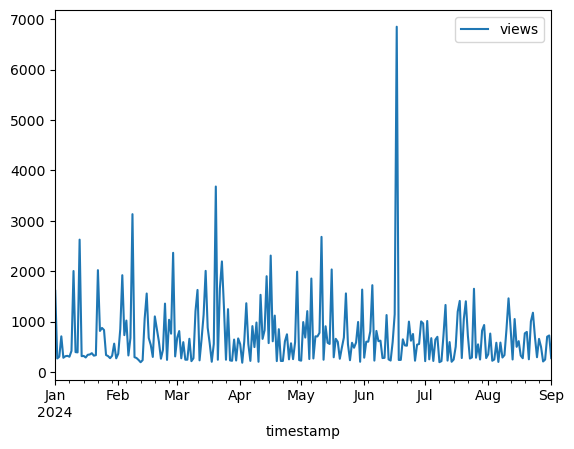

In [68]:
pv_df.set_index('timestamp').loc['2024-01-01':].plot(y='views')

## URLs

Uniform Reference Locators (URLs) are how the targets of a HTTP request are defined. They have a general structure:

`scheme : // userinfo @ host : port / path ? query # fragment`

that we recognize most clearly as something like:

`https://developer.mozilla.org/en-US/docs/Web/HTTP#reference`  

If we wanted to break up the components of a URL to parse or count, we might be tempted to use something like regular expressions, but there is a specific and formal specification implementing this standard, and we should make sure our tools follow it. In this case, let's use the [`urlparse`](https://docs.python.org/3/library/urllib.parse.html) function.


In [69]:
from urllib.parse import urlparse, quote, unquote

In [70]:
kaist_url

'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/KAIST/daily/20230801/20240901'

In [71]:
kaist_url_parsed = urlparse(kaist_url)
kaist_url_parsed

ParseResult(scheme='https', netloc='wikimedia.org', path='/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/KAIST/daily/20230801/20240901', params='', query='', fragment='')

We can access the components of this `ParseResult` as attributes.

In [72]:
kaist_url_parsed.scheme

'https'

In [73]:
kaist_url_parsed.netloc

'wikimedia.org'

Try again with the Mozilla URL.

In [74]:
mozilla_url_parsed = urlparse('https://developer.mozilla.org/en-US/docs/Web/HTTP#reference#test')
mozilla_url_parsed

ParseResult(scheme='https', netloc='developer.mozilla.org', path='/en-US/docs/Web/HTTP', params='', query='', fragment='reference#test')

In [75]:
mozilla_url_parsed.path

'/en-US/docs/Web/HTTP'

In [76]:
mozilla_url_parsed.fragment

'reference#test'

URLs have mixed compatibility with non-ASCII characters. We can use the `quote` and `unquote` to handle encoding and decoding (respectievly) special characters into an ASCII compliant format.

In [77]:
quote('Barack Obama')

'Barack%20Obama'

In [78]:
quote('Beyoncé')

'Beyonc%C3%A9'

In [79]:
unquote('https://en.wikipedia.org/wiki/Barack%20Obama')

'https://en.wikipedia.org/wiki/Barack Obama'

In [80]:
unquote('https://en.wikipedia.org/wiki/Beyonc%C3%A9')

'https://en.wikipedia.org/wiki/Beyoncé'

## Exercises

### Exercise 01: Find an interesting traceroute

Find a safe and interesting traceroute to a server from your computer. Servers that are far away and uncommonly trafficked tend to be the most interesting!

### Exercise 02: Encounter unusual HTTP status codes
Make some requests to web servers with a goal of getting unusual status codes (more than 200, 403, 404, etc.).

### Exercise 03: Change Pageview API HTTP request
Change the URL for the HTTP request for the [Wikipedia Pageviews API](https://doc.wikimedia.org/generated-data-platform/aqs/analytics-api/reference/page-views.html) to different parameters or a different endpoint.

In [94]:
pagecounts_s = 'https://wikimedia.org/api/rest_v1/metrics/legacy/pagecounts/aggregate/{project}/{accesssite}/{granularity}/{start}/{end}'

filled_s = pagecounts_s.format(
    project='en.wikipedia.org',
    accesssite='all-sites',
    granularity='daily',
    start='2009010100',
    end='2015010100'
)

In [96]:
filled_s

'https://wikimedia.org/api/rest_v1/metrics/legacy/pagecounts/aggregate/en.wikipedia.org/all-sites/daily/2009010100/2015010100'

<Axes: xlabel='timestamp'>

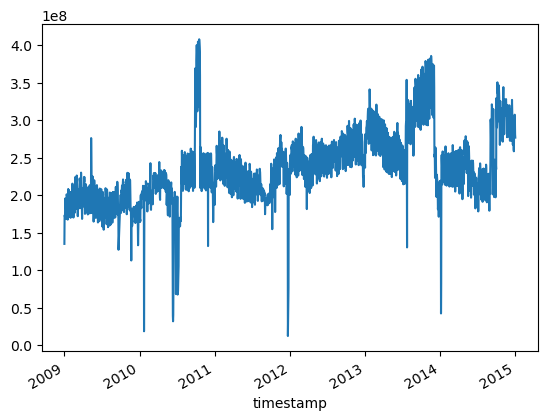

In [97]:
pv_df = pd.DataFrame(requests.get(filled_s,headers=custom_headers).json()['items'])

# Parse the timestamp to a pandas Timestamp format
pv_df['timestamp'] = pd.to_datetime(pv_df['timestamp'],format='%Y%m%d%H')

pv_df.set_index('timestamp')['count'].plot()

### Exercise 04: Quote and request
Use the `quote` function in combination with the API request to get the pageview data about an article with a space or other difficult character in the title.

### Exercise 05: Parse the links on a Wikipedia article
The function `get_wiki_extlinks` function retrieves all the external links on a Wikipedia article. Use `urlparse` to say something about the distribution of citations on an article. 

In [98]:
def get_wiki_extlinks(article_title):
    query_params = {
        'action':'query',
        'titles':article_title,
        'prop':'extlinks',
        'ellimit':500,
        'format':'json'
    }

    response = requests.get(
        'https://en.wikipedia.org/w/api.php', 
        params = query_params
    )

    return response.json()

In [99]:
get_wiki_extlinks('University of Colorado Boulder')

{'batchcomplete': '',
 'query': {'pages': {'289672': {'pageid': 289672,
    'ns': 0,
    'title': 'University of Colorado Boulder',
    'extlinks': [{'*': 'http://www.travelandleisure.com/articles/americas-most-beautiful-college-campuses/21'},
     {'*': 'http://housing.colorado.edu/residences/room-types/residence-hall-rooms'},
     {'*': 'http://www.coloradodaily.com/ci_15841873?source=most_viewed#axzz1KZPSXTJD'},
     {'*': 'http://www.dailycamera.com/ci_15748864'},
     {'*': 'http://www.colorado.edu/centerforcommunity/'},
     {'*': 'https://www.cu.edu/sg/messages/5722.html'},
     {'*': 'http://housing.colorado.edu/dining'},
     {'*': 'http://cuheritage.org/'},
     {'*': 'https://www.cusys.edu/downloads/answerbook.pdf'},
     {'*': 'http://www.colorado.edu/StudentGroups/uchc/home.htm'},
     {'*': 'http://www.colorado.edu/StudentGroups/uchc/slideShows.htm'},
     {'*': 'http://www.radio1190.org/info/history.html'},
     {'*': 'http://www.boulderfreeride.com/'},
     {'*': 'http: